In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
data = pd.read_csv('precios_casas.csv')
df = data.head(9)
print(df)

       price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  \
0   313000.0       3.0       1.50         1340      7912     1.5           0   
1  2384000.0       5.0       2.50         3650      9050     2.0           0   
2   342000.0       3.0       2.00         1930     11947     1.0           0   
3   420000.0       3.0       2.25         2000      8030     1.0           0   
4   550000.0       4.0       2.50         1940     10500     1.0           0   
5   490000.0       2.0       1.00          880      6380     1.0           0   
6   335000.0       2.0       2.00         1350      2560     1.0           0   
7   482000.0       4.0       2.50         2710     35868     2.0           0   
8   452500.0       3.0       2.50         2430     88426     1.0           0   

   view  condition  sqft_above  sqft_basement  yr_built  yr_renovated  \
0     0          3        1340              0      1955          2005   
1     4          5        3370            280      19

In [3]:
#extract the columns
columns = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'condition', 'price']
df = df[columns]
print(df)

   bedrooms  bathrooms  sqft_living  sqft_lot  floors  condition      price
0       3.0       1.50         1340      7912     1.5          3   313000.0
1       5.0       2.50         3650      9050     2.0          5  2384000.0
2       3.0       2.00         1930     11947     1.0          4   342000.0
3       3.0       2.25         2000      8030     1.0          4   420000.0
4       4.0       2.50         1940     10500     1.0          4   550000.0
5       2.0       1.00          880      6380     1.0          3   490000.0
6       2.0       2.00         1350      2560     1.0          3   335000.0
7       4.0       2.50         2710     35868     2.0          3   482000.0
8       3.0       2.50         2430     88426     1.0          4   452500.0


In [4]:
#correlation matrix
correlation_matrix = df.corr()
print(correlation_matrix)

             bedrooms  bathrooms  sqft_living  sqft_lot    floors  condition  \
bedrooms     1.000000   0.687184     0.877273  0.072300  0.713024   0.666973   
bathrooms    0.687184   1.000000     0.792848  0.418165  0.289533   0.583333   
sqft_living  0.877273   0.792848     1.000000  0.320518  0.670557   0.733060   
sqft_lot     0.072300   0.418165     0.320518  1.000000 -0.013604   0.106965   
floors       0.713024   0.289533     0.670557 -0.013604  1.000000   0.133631   
condition    0.666973   0.583333     0.733060  0.106965  0.133631   1.000000   
price        0.721326   0.326434     0.752007 -0.119551  0.611309   0.721246   

                price  
bedrooms     0.721326  
bathrooms    0.326434  
sqft_living  0.752007  
sqft_lot    -0.119551  
floors       0.611309  
condition    0.721246  
price        1.000000  


<Axes: >

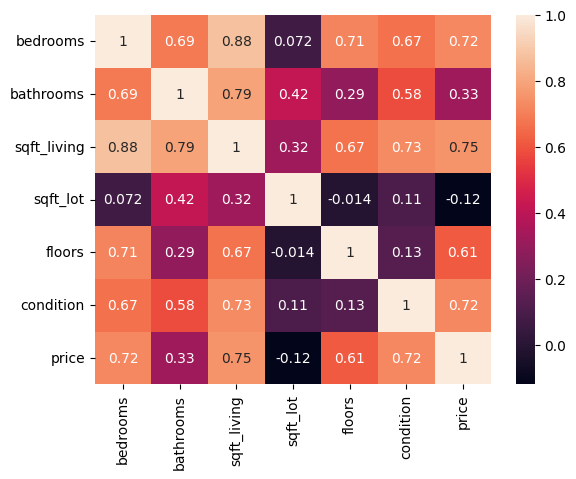

In [5]:
#heatmap
sns.heatmap(correlation_matrix, annot=True)

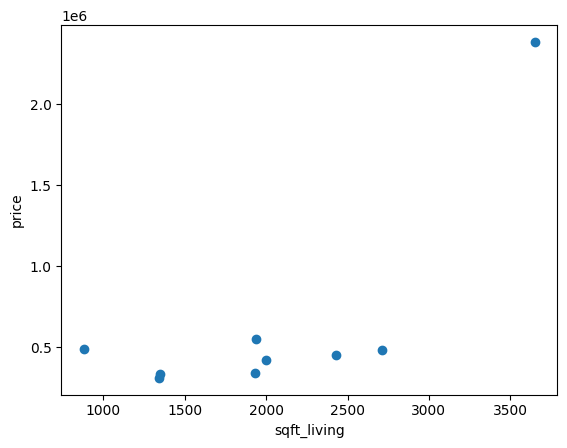

In [6]:
#Como se puede observar en la matriz de correlación, las variables que tienen una correlación más fuerte con el precio son: sqft_living y bathrooms.
#Esto significa que a medida que el tamaño de la casa y el número de baños aumentan, el precio de la casa también aumenta.

x = df['sqft_living']
y = df['price']

plt.scatter(x, y)
plt.xlabel('sqft_living')
plt.ylabel('price')
plt.show()


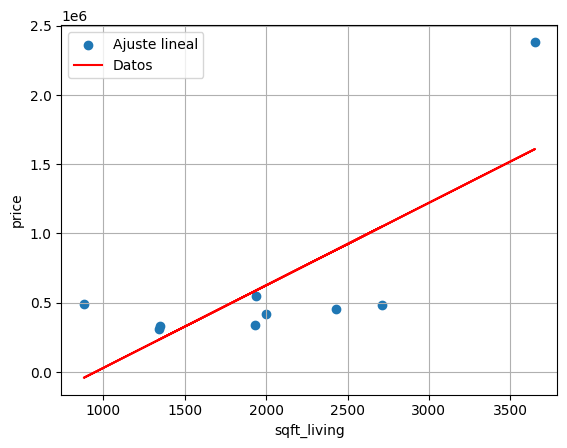

In [7]:
import numpy as np

def calcula_parametros(x, y):
    w1 = np.sum((x - np.mean(x)) * (y - np.mean(y))) / np.sum((x - np.mean(x))**2)
    w0 = np.mean(y) - w1 * np.mean(x)
    return float(w0), float(w1)

w0, w1 = calcula_parametros(x, y)

plt.figure
plt.scatter(x, y)
plt.plot(x, w0 + w1*x, color='red')
plt.xlabel('sqft_living')
plt.ylabel('price')
plt.legend(['Ajuste lineal', 'Datos'])
plt.grid()
plt.show() 

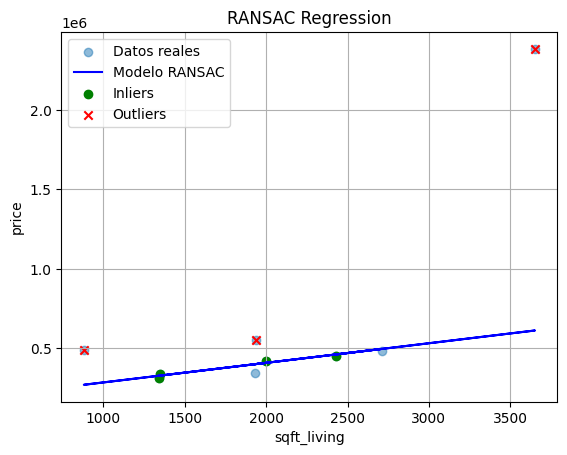

In [8]:

from sklearn.linear_model import RANSACRegressor, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


# Reestructurar para asegurar el formato correcto
x = x.values.reshape(-1, 1)
y = y.values.reshape(-1, 1)


# Dividir en conjunto de entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

# Crear modelo RANSAC
model = RANSACRegressor(estimator=LinearRegression(), max_trials=100, random_state=0)
model.fit(x_train, y_train)

# Predecir resultados
y_pred = model.predict(x_test)

# Señalamos los inliers y outliers (solo para datos de entrenamiento)
inliers = model.inlier_mask_
outliers = np.logical_not(inliers)


# Graficar resultados
plt.scatter(x, y, label='Datos reales', alpha=0.5)
plt.plot(x, model.predict(x), color='blue', label='Modelo RANSAC')
plt.scatter(x_train[inliers], y_train[inliers], color='green', marker='o', label='Inliers')
plt.scatter(x_train[outliers], y_train[outliers], color='red', marker='x', label='Outliers')
plt.xlabel('sqft_living')
plt.ylabel('price')
plt.legend()
plt.title('RANSAC Regression')
plt.grid()

plt.show()


